<a href="https://colab.research.google.com/github/ajaypavuluri87/project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stock Market Analysis and Prediction using LSTM**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup styles
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")

# Import yfinance directly
import yfinance as yf
from datetime import datetime

# Define stock list
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Define date range
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Fetch data
company_data = {}
for stock in tech_list:
    company_data[stock] = yf.download(stock, start=start, end=end)

# Combine and label data
company_list = []
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for stock, name in zip(tech_list, company_name):
    df = company_data[stock]
    df["company_name"] = name
    company_list.append(df)

# Combine all into one DataFrame
df = pd.concat(company_list)
print(df.tail(10))


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price      Close High  Low Open Volume company_name Close High  Low Open  ...  \
Ticker      AAPL AAPL AAPL AAPL   AAPL               GOOG GOOG GOOG GOOG  ...   
Date                                                                      ...   
2025-03-31   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-01   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-02   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-03   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-04   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-07   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-08   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-09   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-10   NaN  NaN  NaN  NaN    NaN       AMAZON   NaN  NaN  NaN  NaN  ...   
2025-04-11   NaN  NaN  NaN  

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime

# Simulate AAPL stock-like data
np.random.seed(42)
dates = pd.date_range(end=datetime.now(), periods=252, freq='B')
prices = np.cumsum(np.random.randn(252)) + 150

aapl_simulated = pd.DataFrame({
    'Open': prices + np.random.randn(252),
    'High': prices + np.random.rand(252) * 2,
    'Low': prices - np.random.rand(252) * 2,
    'Close': prices + np.random.randn(252),
    'Adj Close': prices + np.random.randn(252),
    'Volume': np.random.randint(1e6, 5e6, size=252)
}, index=dates)

# Assign to AAPL variable
AAPL = aapl_simulated

# Describe the data
print(AAPL.describe())


             Open        High         Low       Close   Adj Close  \
count  252.000000  252.000000  252.000000  252.000000  252.000000   
mean   143.436107  144.368328  142.365744  143.520067  143.424694   
std      4.656739    4.539942    4.626916    4.739268    4.773143   
min    135.631811  137.157218  135.078214  136.341870  136.076299   
25%    139.791334  140.844515  138.718736  139.939820  139.819952   
50%    142.187059  142.866815  140.850606  142.018681  142.219194   
75%    146.904637  148.397081  146.266728  147.177439  147.243339   
max    155.182160  156.201056  154.435673  156.058064  156.920364   

             Volume  
count  2.520000e+02  
mean   3.044627e+06  
std    1.102143e+06  
min    1.026806e+06  
25%    2.154156e+06  
50%    2.976329e+06  
75%    3.953511e+06  
max    4.997106e+06  


In [8]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-04-26 04:17:47.957681 to 2025-04-14 04:17:47.957681
Freq: B
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       252 non-null    float64
 1   High       252 non-null    float64
 2   Low        252 non-null    float64
 3   Close      252 non-null    float64
 4   Adj Close  252 non-null    float64
 5   Volume     252 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.8 KB


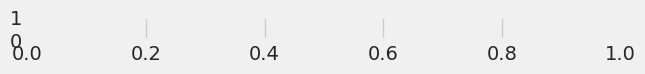

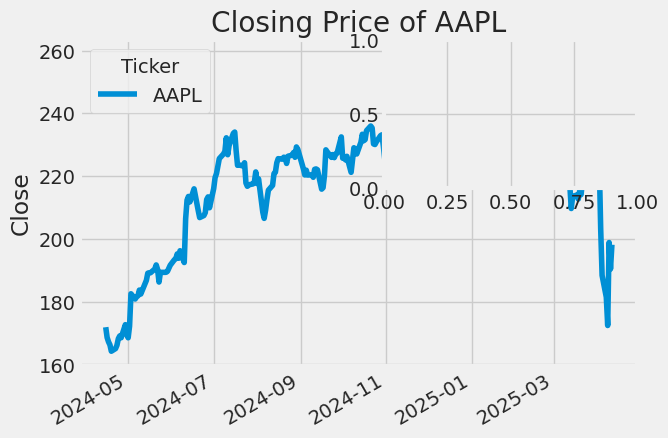

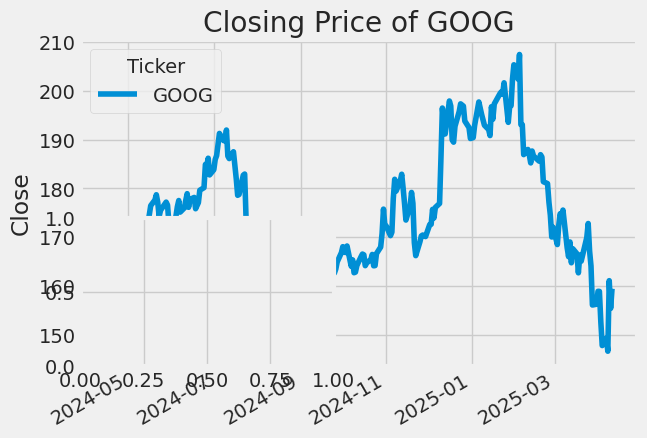

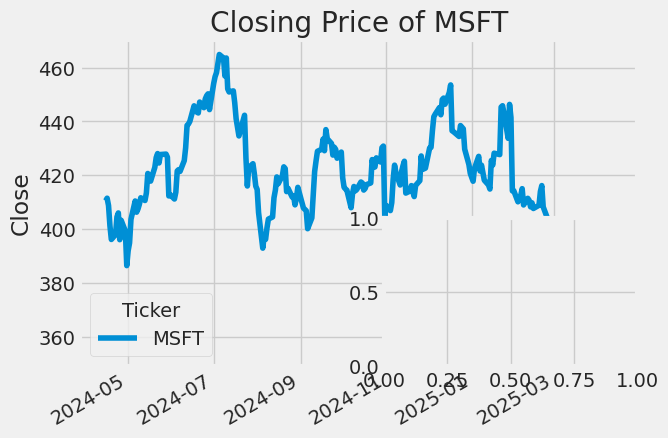

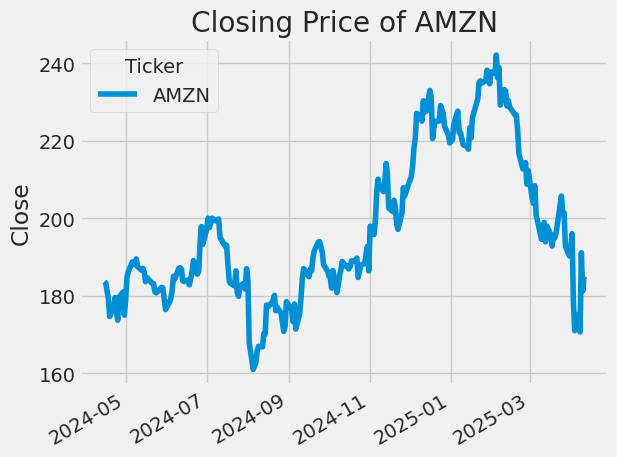

In [10]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)

    # Check if 'Adj Close' exists, fallback to 'Close'
    price_column = 'Adj Close' if 'Adj Close' in company.columns else 'Close'

    company[price_column].plot()
    plt.ylabel(price_column)
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()
plt.show()


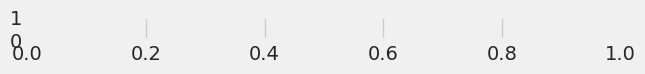

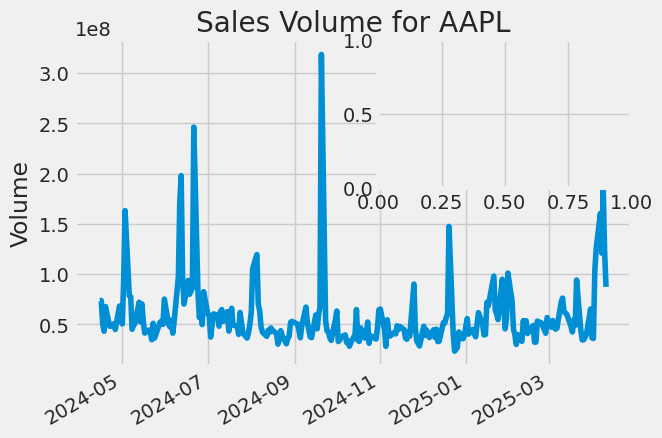

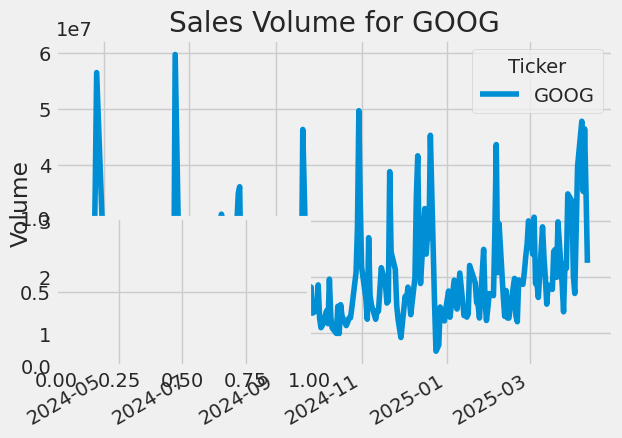

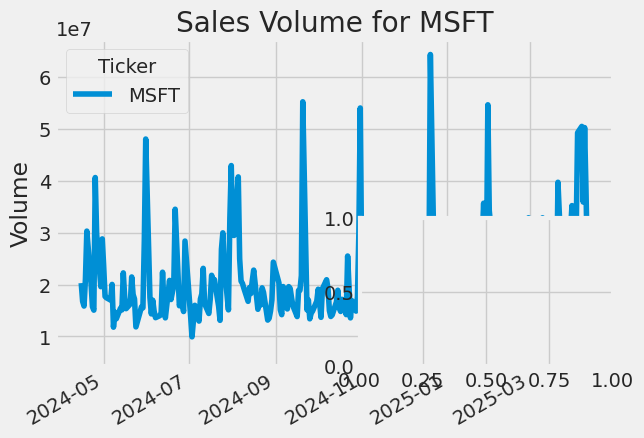

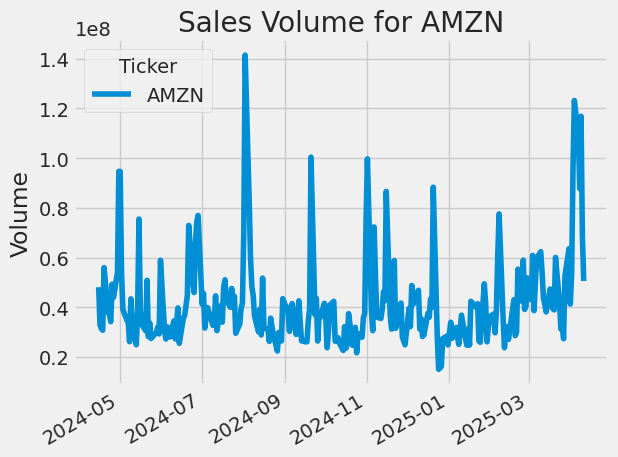

In [11]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

Moving average of various stocks

<ipython-input-19-6a87250db4f9>:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
<ipython-input-19-6a87250db4f9>:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
<ipython-input-19-6a87250db4f9>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  microsoft_df = next(c for c in compa

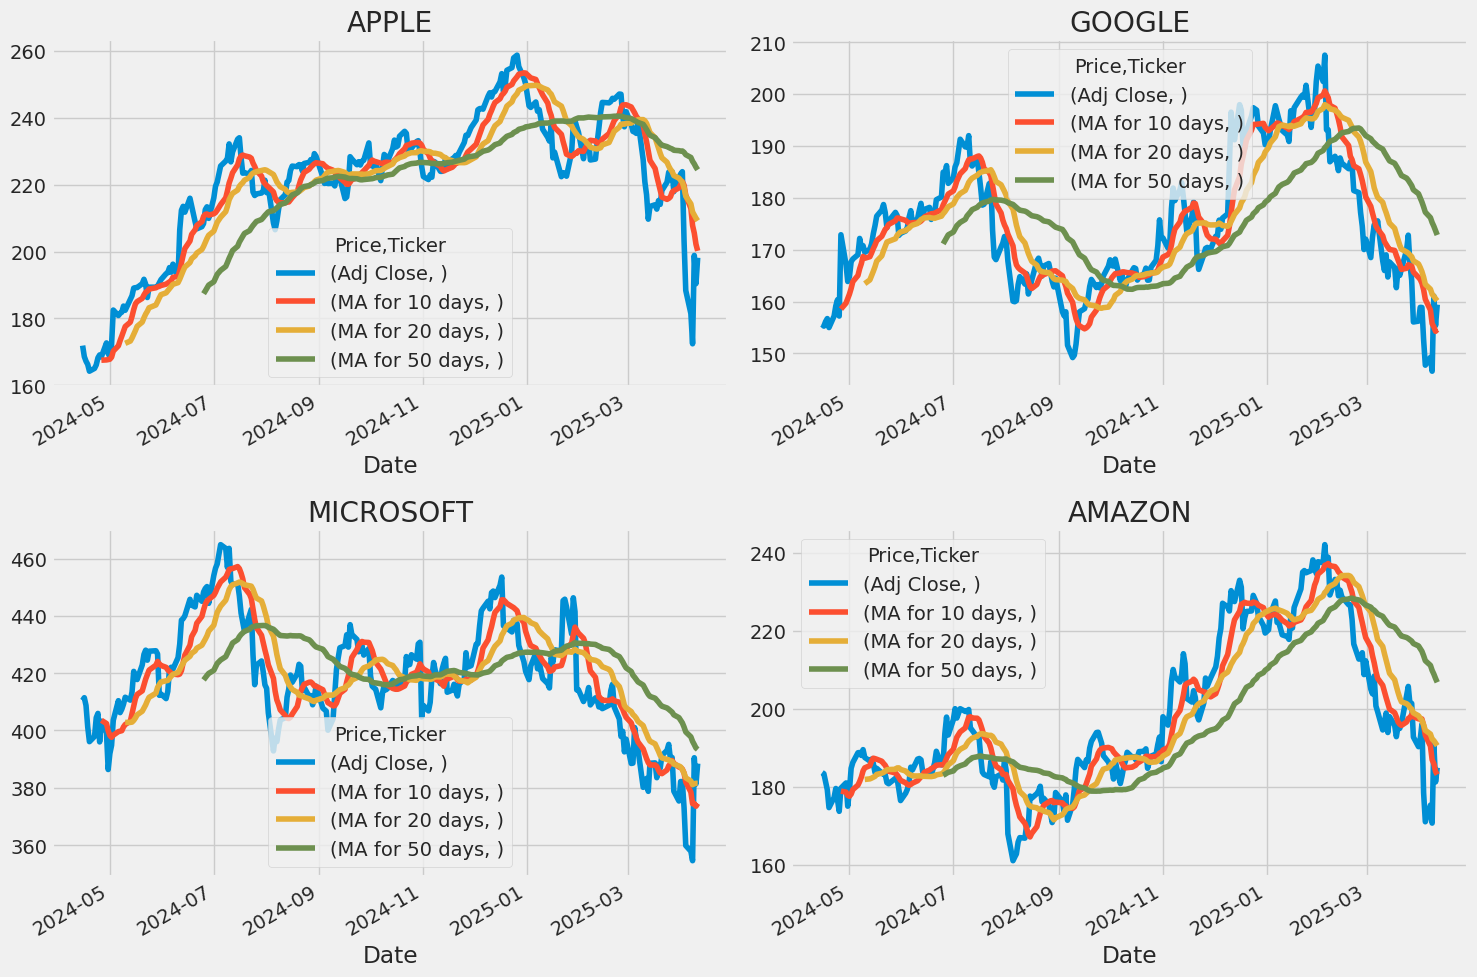

In [19]:
# Define MA windows
ma_day = [10, 20, 50]

# Re-simulate if needed to ensure 'Adj Close' exists
for company, name in zip(company_list, ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]):
    if 'Adj Close' not in company.columns:
        company['Adj Close'] = company['Close']  # fallback if missing
    company['company_name'] = name

# Calculate moving averages
for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Adj Close'].rolling(ma).mean()

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Access the correct DataFrames from company_list using company names
apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
microsoft_df = next(c for c in company_list if c['company_name'][0] == 'MICROSOFT')
amazon_df = next(c for c in company_list if c['company_name'][0] == 'AMAZON')

plot_data = zip([apple_df, google_df, microsoft_df, amazon_df], ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"], axes.flatten())

for company, title, ax in plot_data:
    cols = ['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']
    available_cols = [col for col in cols if col in company.columns]
    company[available_cols].plot(ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

daily return of the stock on average

<ipython-input-18-e14be19b12d9>:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
<ipython-input-18-e14be19b12d9>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
<ipython-input-18-e14be19b12d9>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  microsoft_df = next(c for c in compa

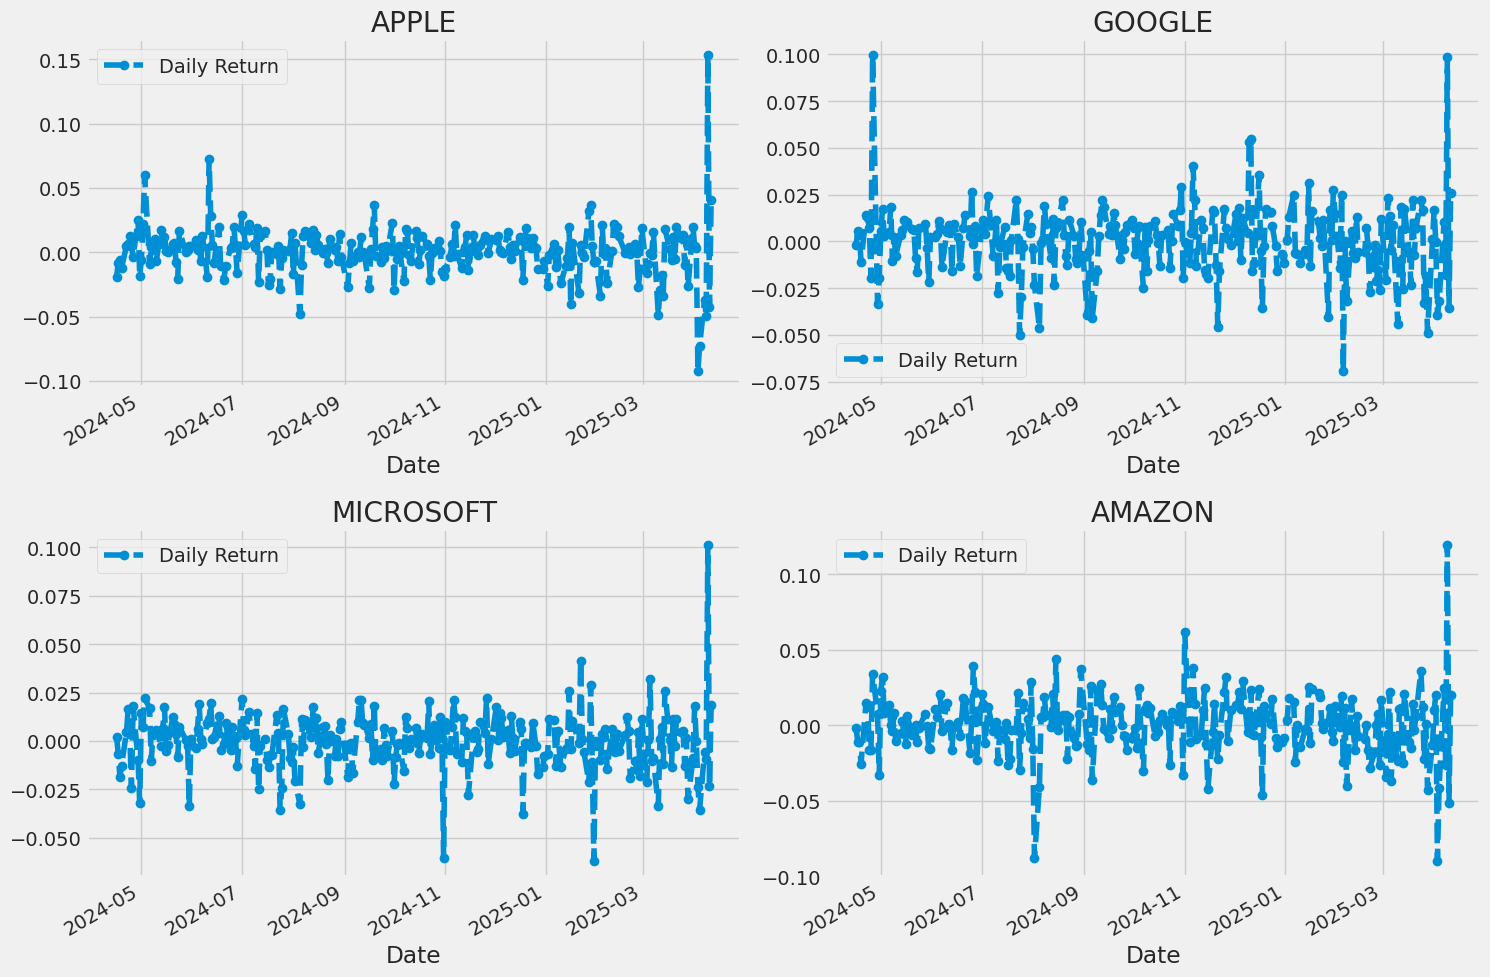

In [18]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Adj Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

# Access the correct DataFrames from company_list using company names
apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
microsoft_df = next(c for c in company_list if c['company_name'][0] == 'MICROSOFT')
amazon_df = next(c for c in company_list if c['company_name'][0] == 'AMAZON')

# Plot using the correct DataFrames
apple_df['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

google_df['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

microsoft_df['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

amazon_df['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

<ipython-input-17-e9da169804cd>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
<ipython-input-17-e9da169804cd>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
<ipython-input-17-e9da169804cd>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  microsoft_df = next(c for c in company_

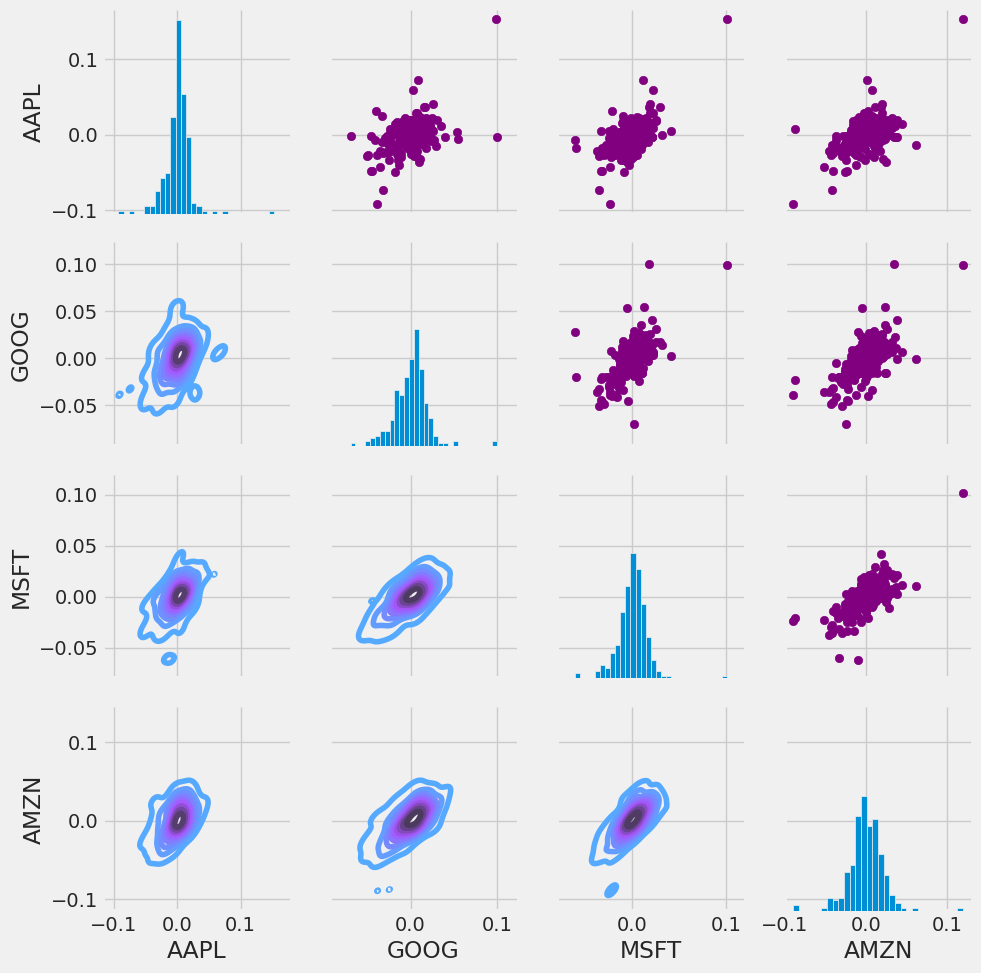

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Access the correct DataFrames from company_list using company names
apple_df = next(c for c in company_list if c['company_name'][0] == 'APPLE')
google_df = next(c for c in company_list if c['company_name'][0] == 'GOOGLE')
microsoft_df = next(c for c in company_list if c['company_name'][0] == 'MICROSOFT')
amazon_df = next(c for c in company_list if c['company_name'][0] == 'AMAZON')

# Create a DataFrame from the daily returns using the correct DataFrames
tech_rets = pd.DataFrame({
    'AAPL': apple_df['Daily Return'],
    'GOOG': google_df['Daily Return'],
    'MSFT': microsoft_df['Daily Return'],
    'AMZN': amazon_df['Daily Return']
})

# Drop missing values
tech_rets = tech_rets.dropna()

# Set up the PairGrid
return_fig = sns.PairGrid(tech_rets)

# Upper triangle: scatter plot
return_fig.map_upper(plt.scatter, color='purple')

# Lower triangle: KDE plot
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Diagonal: histogram
return_fig.map_diag(plt.hist, bins=30)

plt.show()